In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

In [ ]:
# Take crop_player in video
for track_id, player in tracks['players'][3].items():
        bbox = player['bbox']
        frame = video_frames[3]

        cropped = frame[int(bbox[1]):int(bbox[3]),int(bbox[0]):int(bbox[2])]

        cv2.imwrite(f'output_videos/cropped_img.jpg',cropped)
        break
#NOTE: Do it in main to take cropped image easier 

In [ ]:
image_path = '../output_videos/cropped_img.jpg'
image = cv2.imread(image_path)
image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

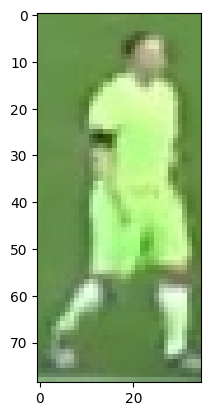

In [17]:
plt.imshow(image)
plt.show()

# Take the shirt partern
### Take the top half of the image

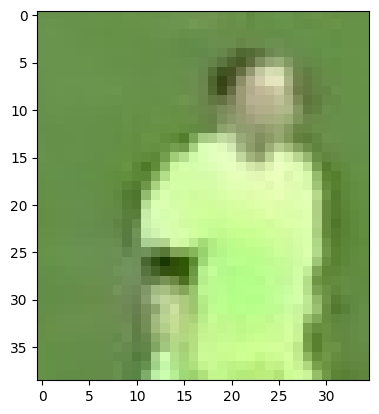

In [18]:
shirt = image[0: int (image.shape[0]/2),:]
plt.imshow(shirt)

# Cluster image into 2 clusters

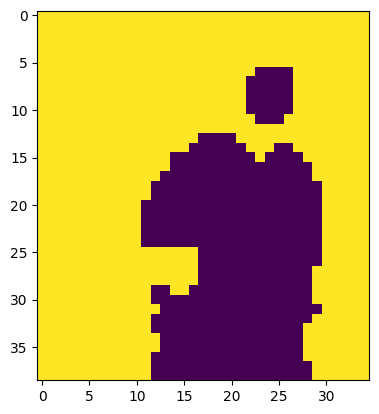

In [19]:
# Reshape the image into 2d array
image_2d = shirt.reshape(-1,3)

# Using k-mean clustering with 2 clusters
kmeans = KMeans(n_clusters= 2, random_state=0)
kmeans.fit(image_2d)

# get the cluster labels
labels = kmeans.labels_

# reshape the labels to original image shape
clustered_img = labels.reshape(shirt.shape[0], shirt.shape[1])


# Display
plt.imshow(clustered_img)
plt.show()


In [22]:
Coner_cluster = [clustered_img[0,0],clustered_img[0,-1],clustered_img[-1,0],clustered_img[-1,-1]]
non_player_cluster = max(set(Coner_cluster),key = Coner_cluster.count)
print(non_player_cluster)

1


In [23]:
player_cluster = 1-non_player_cluster
print(player_cluster)

0


In [24]:
kmeans.cluster_centers_[player_cluster]

array([197.19483568, 238.68779343, 150.74413146])